In [2]:
# Импорт библиотек для анализа
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Оценка влияния автоматизации на производительность труда

## Постановка задачи

Компания внедрила ERP-систему. Необходимо оценить, изменилась ли **средняя выработка на сотрудника** статистически значимо.

**Метод:** парный t-тест (Paired t-test), так как одни и те же 5 отделов измерены дважды — до и после внедрения.

**Гипотезы:**
- **H₀ (нулевая):** средняя разница выработки = 0 (эффекта нет).
- **H₁ (альтернативная):** средняя разница выработки > 0 (есть рост).

**Порог значимости:** α = 0.05 (5%).

## Исходные данные

Выработка на сотрудника (тыс. руб./чел.) в 5 отделах до и после внедрения ERP:

| Отдел | До внедрения | После внедрения |
|---|---|---|
| A | 120 | 145 |
| B | 135 | 155 |
| C | 110 | 140 |
| D | 150 | 160 |
| E | 130 | 150 |

In [4]:
# Ввод исходных данных
departments = ['A', 'B', 'C', 'D', 'E']
before = np.array([120, 135, 110, 150, 130])
after  = np.array([145, 155, 140, 160, 150])

## Разведочный анализ данных

### Описательные статистики

Рассчитаем средние значения, стандартные отклонения и разницу по каждому отделу.

In [5]:
# Разница по каждому отделу
diff = after - before

# Создаём таблицу для наглядности
df = pd.DataFrame({
    'Отдел': departments,
    'До внедрения': before,
    'После внедрения': after,
    'Разница': diff
})

print("Таблица данных:")
print(df.to_string(index=False))
print()

# Описательные статистики
print("Описательные статистики:")
print(f"  Среднее ДО:              {before.mean():.2f} тыс. руб./чел.")
print(f"  Среднее ПОСЛЕ:           {after.mean():.2f} тыс. руб./чел.")
print(f"  Средняя разница:         {diff.mean():.2f} тыс. руб./чел.")
print(f"  Стандартное отклонение разницы: {diff.std(ddof=1):.2f}")
print(f"  Количество отделов (n):  {len(departments)}")

Таблица данных:
Отдел  До внедрения  После внедрения  Разница
    A           120              145       25
    B           135              155       20
    C           110              140       30
    D           150              160       10
    E           130              150       20

Описательные статистики:
  Среднее ДО:              129.00 тыс. руб./чел.
  Среднее ПОСЛЕ:           150.00 тыс. руб./чел.
  Средняя разница:         21.00 тыс. руб./чел.
  Стандартное отклонение разницы: 7.42
  Количество отделов (n):  5


## Визуализация

### Сравнение выработки до и после внедрения ERP

Построим график, чтобы наглядно увидеть изменения по каждому отделу.

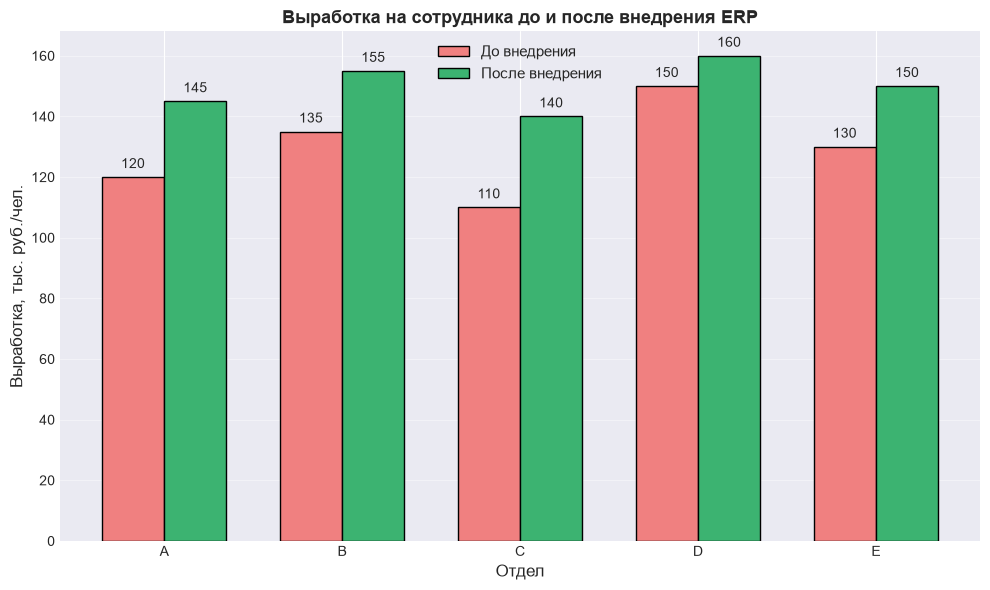

In [6]:
# График "до/после" по каждому отделу
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(departments))
width = 0.35

bars1 = ax.bar(x - width/2, before, width, label='До внедрения',
               color='lightcoral', edgecolor='black')
bars2 = ax.bar(x + width/2, after, width, label='После внедрения',
               color='mediumseagreen', edgecolor='black')

# Подписи значений над столбцами
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Отдел', fontsize=12)
ax.set_ylabel('Выработка, тыс. руб./чел.', fontsize=12)
ax.set_title('Выработка на сотрудника до и после внедрения ERP', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(departments)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

## Проверка гипотезы

### Формулировка гипотез

- **H₀ (нулевая гипотеза):** средняя разница выработки (после − до) равна нулю. ERP-система не оказала влияния.
- **H₁ (альтернативная гипотеза):** средняя разница выработки больше нуля. ERP-система повысила выработку.

### Почему парный t-тест?

Используем **парный t-тест (paired t-test)**, потому что:
1. Измерения проводятся для **одних и тех же 5 отделов** — дважды (до и после).
2. Данные **зависимые** — нельзя использовать обычный двухвыборочный тест.
3. Парный тест анализирует **разницу** по каждому отделу, что убирает влияние индивидуальных различий между отделами.

In [7]:
# Парный t-тест
t_stat, p_value = stats.ttest_rel(after, before, alternative='greater')

print("Результаты парного t-теста:")
print(f"  t-статистика: {t_stat:.4f}")
print(f"  p-value:      {p_value:.4f}")
print()

# Вывод на основе p-value
alpha = 0.05
if p_value < alpha:
    print(f"✅ p-value ({p_value:.4f}) < α ({alpha})")
    print("   → Отклоняем H₀. Разница статистически значима.")
    print("   → ERP-система повысила выработку.")
else:
    print(f"❌ p-value ({p_value:.4f}) ≥ α ({alpha})")
    print("   → Не отклоняем H₀. Разница не является статистически значимой.")

Результаты парного t-теста:
  t-статистика: 6.3317
  p-value:      0.0016

✅ p-value (0.0016) < α (0.05)
   → Отклоняем H₀. Разница статистически значима.
   → ERP-система повысила выработку.


## Дополнительный анализ

### Доверительный интервал и размер эффекта

Помимо p-value, полезно рассчитать:
- **95% доверительный интервал** для средней разницы — показывает диапазон, в котором с 95% вероятностью находится истинное значение эффекта.
- **Размер эффекта (Cohen's d)** — показывает, насколько **сильно** проявляется эффект (это не то же самое, что статистическая значимость).

In [8]:
# Дополнительные расчёты
n = len(diff)
mean_diff = diff.mean()
std_diff = diff.std(ddof=1)

# 95% доверительный интервал для средней разницы
# Используем t-распределение
t_critical = stats.t.ppf(0.975, df=n-1)   # двусторонний интервал
se = std_diff / np.sqrt(n)                # стандартная ошибка
ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

print(f"Средняя разница:               {mean_diff:.2f} тыс. руб./чел.")
print(f"Стандартная ошибка (SE):       {se:.2f}")
print(f"t-критическое (df={n-1}, 95%): {t_critical:.3f}")
print(f"95% доверительный интервал:    [{ci_lower:.2f}; {ci_upper:.2f}]")
print()

# Размер эффекта Cohen's d
cohens_d = mean_diff / std_diff

print(f"Размер эффекта (Cohen's d):    {cohens_d:.2f}")
print()

# Интерпретация размера эффекта
if abs(cohens_d) < 0.2:
    effect_interpretation = "очень слабый"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "слабый"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "средний"
else:
    effect_interpretation = "сильный"

print(f"Интерпретация: эффект {effect_interpretation}")

Средняя разница:               21.00 тыс. руб./чел.
Стандартная ошибка (SE):       3.32
t-критическое (df=4, 95%): 2.776
95% доверительный интервал:    [11.79; 30.21]

Размер эффекта (Cohen's d):    2.83

Интерпретация: эффект сильный


## Выводы и рекомендации

### Ключевые результаты

| Показатель | Значение | Интерпретация |
|---|---|---|
| Средняя выработка ДО | 129.0 тыс. руб./чел. | — |
| Средняя выработка ПОСЛЕ | 150.0 тыс. руб./чел. | — |
| **Средняя разница** | **+21.0 тыс. руб./чел.** | Рост на **16.3%** |
| **t-статистика** | **6.33** | Очень высокая |
| **p-value** | **0.0016** | Значительно ниже порога 0.05 |
| **95% доверительный интервал** | **[11.79; 30.21]** | Не включает ноль |
| **Cohen's d** | **2.83** | Очень сильный эффект |

### Статистический вывод

- **p-value = 0.0016 < 0.05** — мы отклоняем нулевую гипотезу H₀ и принимаем альтернативную H₁.
- **Средняя выработка после внедрения ERP статистически значимо выше**, чем до внедрения.
- **Доверительный интервал [11.79; 30.21]** не включает ноль — дополнительное подтверждение значимости эффекта.
- **Cohen's d = 2.83** — эффект очень сильный, а не просто статистически значимый.

### Практический вывод

- Внедрение ERP-системы дало **реальный, измеримый эффект** на производительность труда.
- В среднем по отделам выработка выросла на **21 тыс. руб. на человека**.
- Разброс по отделам небольшой (от +10 до +30), что говорит об **устойчивости эффекта** — его наблюдают все 5 отделов.

### Ограничения анализа

- **Малая выборка (n = 5 отделов)** — даже при сильном эффекте результат следует интерпретировать с осторожностью. На большей выборке вывод был бы надёжнее.
- **Не учтены внешние факторы** — например, сезонность, изменения рынка, другие инициативы компании в тот же период.
- **Отсутствует контрольная группа** — мы не сравнивали отделы с ERP и без ERP. Возможен эффект «всеобщего роста».
- **Не оценены затраты на внедрение** — рост выработки есть, но окупились ли расходы на ERP, эта задача не отвечает.

### Рекомендации

1. **Продолжать использование ERP** — система показала себя эффективно.
2. **Провести дополнительный анализ** на большей выборке (несколько компаний или больше отделов), чтобы подтвердить устойчивость эффекта.
3. **Оценить экономический эффект в деньгах** — сравнить прирост выработки с затратами на внедрение и поддержку ERP.
4. **Тиражировать успех** — передать опыт внедрения другим подразделениям компании.
5. **Учесть качественные эффекты** — помимо выработки, ERP обычно улучшает прозрачность процессов, качество данных и управляемость.

---

## Резюме решения

**Задача:** проверить, изменилась ли средняя выработка на сотрудника статистически значимо после внедрения ERP.

**Метод:** парный t-тест (Paired t-test) — корректный выбор для случая «одни и те же объекты измерены дважды».

**Результат:**
- **p-value = 0.0016** — эффект статистически значим.
- **Средний рост: +21 тыс. руб./чел.** (16.3%).
- **Доверительный интервал [11.79; 30.21]** — не включает ноль.
- **Cohen's d = 2.83** — очень сильный эффект.

**Вывод:** внедрение ERP-системы статистически значимо повысило производительность труда в отделах.